# Reconciliation Automation Engine

## Overview

This notebook demonstrates the complete reconciliation workflow implemented in this project.

## Pipeline

1. Load CSV datasets
2. Normalize data
3. Compare records
4. Perform fuzzy matching
5. Detect mismatches
6. Generate reports
7. Generate analytics
8. Visualize results

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

sys.path.append("../src")

In [2]:
from config import (SOURCE_FILE, TARGET_FILE, REPORTS_DIR)

In [7]:
print("Configuration")

print("-----------------------------------------------------------------------------------")

print("Source File :", SOURCE_FILE)

print("Target File :", TARGET_FILE)

print("Reports Dir :", REPORTS_DIR)

Configuration
-----------------------------------------------------------------------------------
Source File : C:\Users\ASUS\Desktop\Projects\reconciliation_engine\data\source.csv
Target File : C:\Users\ASUS\Desktop\Projects\reconciliation_engine\data\target.csv
Reports Dir : C:\Users\ASUS\Desktop\Projects\reconciliation_engine\reports


In [8]:
from load_data import (load_source_file, load_target_file)

## Load Dataset

In [9]:
source_df = load_source_file()

target_df = load_target_file()

print(f"Source Records : {len(source_df)}")

print(f"Target Records : {len(target_df)}")

Source Records : 1000
Target Records : 986


In [10]:
source_df.head()

,invoice_id,customer_name,invoice_date,amount
0,INV000001,KAI SRINIVAS,19/10/2025,6449
1,INV000002,WILLIAM PANDEY,22/11/2025,40369
2,INV000003,WARINDER RATTAN,18/10/2025,48432
3,INV000004,YACHANA PATLA,11/06/2025,8059
4,INV000005,CHAMAN HORA,26/10/2025,37358


In [11]:
target_df.head()

,invoice_id,customer_name,invoice_date,amount
0,INV000001,KAI SRINIVAS,19/10/2025,6449
1,INV000002,WILLIAM PANDEY,22/11/2025,40369
2,INV000003,WARINDER RATTAN,18/10/2025,48432
3,INV000004,YACHANA PATLA,11/06/2025,8059
4,INV000005,CHAMAN HORA,26/10/2025,37358


## Normalize Data

In [12]:
from normalize_data import (normalize_names, normalize_dates, normalize_amounts)

In [13]:
source_df = normalize_names(source_df)
source_df = normalize_dates(source_df)
source_df = normalize_amounts(source_df)

target_df = normalize_names(target_df)
target_df = normalize_dates(target_df)
target_df = normalize_amounts(target_df)

print("Normalization completed.")

Normalization completed.


In [14]:
source_df.head()

,invoice_id,customer_name,invoice_date,amount
0,INV000001,kai srinivas,2025-10-19,6449.0
1,INV000002,william pandey,2025-11-22,40369.0
2,INV000003,warinder rattan,2025-10-18,48432.0
3,INV000004,yachana patla,2025-11-06,8059.0
4,INV000005,chaman hora,2025-10-26,37358.0


In [15]:
target_df.head()

,invoice_id,customer_name,invoice_date,amount
0,INV000001,kai srinivas,2025-10-19,6449.0
1,INV000002,william pandey,2025-11-22,40369.0
2,INV000003,warinder rattan,2025-10-18,48432.0
3,INV000004,yachana patla,2025-11-06,8059.0
4,INV000005,chaman hora,2025-10-26,37358.0


## Excat Record Comparison

In [16]:
from compare_data import compare_records

In [17]:
results = compare_records(source_df, target_df)

comparison_df = pd.DataFrame(results)

comparison_df.head()

,invoice_id,status
0,INV000001,MATCHED
1,INV000002,MATCHED
2,INV000003,MATCHED
3,INV000004,MATCHED
4,INV000005,MATCHED


## Mismatch Detection

In [18]:
from mismatch_detector import detect_mismatches

In [21]:
mismatches = detect_mismatches(source_df, target_df)

mismatch_df = pd.DataFrame(mismatches)

print(f"Total mismatches: {len(mismatch_df)}")

mismatch_df.head()

Total mismatches: 52


,invoice_id,issue,source,target
0,INV000011,DATE_MISMATCH,2025-04-25,2024-11-08
1,INV000018,DATE_MISMATCH,2025-04-14,2025-09-25
2,INV000074,DATE_MISMATCH,2025-03-03,2026-06-15
3,INV000102,CUSTOMER_MISMATCH,upma prabhakar,pahal rajagopalan
4,INV000113,DATE_MISMATCH,2026-06-02,2025-05-07


## RapidFuzz Similarity Matching

In [22]:
from fuzzy_matcher import (calculate_similarity, is_probable_match)

In [23]:
name1 = "Abhiram TK"

name2 = "Abiram TK"

score = calculate_similarity(name1, name2)

print("Similarity Score :", score)

print("Probable Match :", is_probable_match(name1, name2))

Similarity Score : 94.73684210526316
Probable Match : True


## Generate Reports

In [24]:
from report_generator import generate_reports

In [25]:
generate_reports(results)

print("Reports generated successfully.")

Reports generated successfully.


## Generated Report Files

In [28]:
from pathlib import Path

reports_path = Path("../reports")

print("Generated Files")

for file in reports_path.rglob("*"):

    if file.is_file():

        print(file.relative_to(reports_path))

Generated Files
matched.csv
mismatched.csv
missing.csv
summary.csv
charts\reconciliation_summary.png


## Preview Reports

In [29]:
pd.read_csv("../reports/matched.csv").head()

,invoice_id,status
0,INV000001,MATCHED
1,INV000002,MATCHED
2,INV000003,MATCHED
3,INV000004,MATCHED
4,INV000005,MATCHED


In [30]:
pd.read_csv("../reports/mismatched.csv").head()

,invoice_id,status
0,INV000102,MISMATCHED
1,INV000128,MISMATCHED
2,INV000130,MISMATCHED
3,INV000159,MISMATCHED
4,INV000173,MISMATCHED


In [31]:
pd.read_csv("../reports/missing.csv").head()

,invoice_id,status
0,INV000201,MISSING
1,INV000404,MISSING
2,INV000423,MISSING
3,INV000447,MISSING
4,INV000482,MISSING


## Analytics

In [32]:
from analytics import (generate_summary, save_summary, generate_chart)

In [33]:
summary_df = generate_summary(comparison_df)

summary_df

,Status,Count
0,MATCHED,963
1,MISMATCHED,23
2,MISSING,14


In [34]:
save_summary(summary_df)

generate_chart(summary_df)

In [35]:
pd.read_csv("../reports/summary.csv")

,Status,Count
0,MATCHED,963
1,MISMATCHED,23
2,MISSING,14


## Visualization

In [36]:
from IPython.display import Image

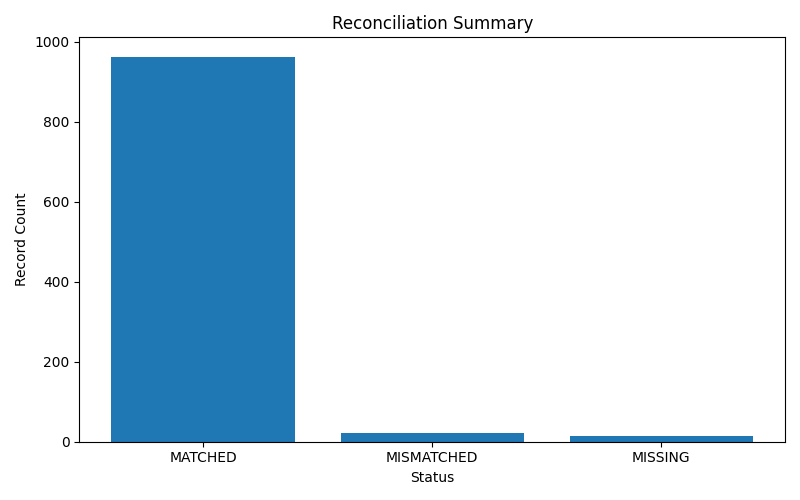

In [38]:
Image("../reports/charts/reconciliation_summary.png")

# Conclusion

This notebook demonstrates the complete reconciliation workflow implemented in the Reconciliation Automation Engine.

Completed Pipeline

- Dataset Generation
- Configurable File Loading
- Data Normalization
- Exact Record Comparison
- Mismatch Detection
- RapidFuzz Similarity Matching
- Report Generation
- Summary Analytics
- Visualization

Generated Artifacts

- matched.csv
- mismatched.csv
- missing.csv
- summary.csv
- reconciliation_summary.png

The notebook validates the complete ETL and reconciliation process using the same reusable modules executed by the application's main pipeline.